In [2]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from pathlib import Path

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# path to data

In [3]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]
meta  = LegendMetadata(config["metadata"])

# ATTENZIONE A RUN
chmap = meta.channelmap(meta.dataprod.runinfo.p03.r001.phy.start_key)

In [4]:
# Qui posso veedere quale è la versione giusta di hit (o altro che mis erve)
# a cui punta il mio file di config ovvero, in questo caso, la versione v2..1.5 e dalla quale posso caricare per gli studi dei QC

config['tier_pet']

'/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest/generated/tier/pet'

# get files

In [5]:
# PRENDO I DATI DI FISICA E NON DI CALIBRAZIONE f"{config["tier_psp"]}/cal/p03/r000/*.lh5" ---> f"{config["tier_psp"]}/phy/p03/r000/*.lh5"
# ATTENZIONE AI RUN
pet_files = sorted(glob.glob(f"{config["tier_pet"]}/phy/l200-p03-r001-phy-tier_pet.lh5"))
psp_files = sorted(glob.glob(f"{config["tier_psp"]}/phy/p03/r001/*.lh5")) #access exsiting DSP-processed data such as the energy for partitions
tcm_files = sorted(glob.glob(f"{config["tier_tcm"]}/phy/p03/r001/*.lh5"))  # --> solo per il pulse
raw_files = sorted(glob.glob(f"{config["tier_raw"]}/phy/p03/r001/*.lh5"))

channel = f'ch{chmap.V02160A.daq.rawid}'
detector = "V02160A"
channel

In [6]:
 f"{config["par_pht"]}/cal/p03/r001"

'/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest/../v2.1.0/generated/par/pht/cal/p03/r001'

In [7]:
channel = f'ch{chmap.V02160A.daq.rawid}'
detector = "V02160A"
channel

'ch1104000'

In [8]:
# The cal_dict we can pull from a hit_results file generated by the dataflow
# ATTENZIONE AL RUN e AL TIMESTAMP
cal_file = f"{config["par_pht"]}/cal/p03/r001/l200-p03-r001-cal-20230317T211819Z-par_pht.json"
cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]



In [9]:
cal = Props.read_from(cal_file)

# Functions

In [10]:
def classifier_fun(data, cal_dict, param):
    a_class = cal_dict[f"is_valid_{param}_classifier"]['parameters']['a']
    b_class = cal_dict[f"is_valid_{param}_classifier"]['parameters']['b']
    
    classifier = (data[f"{param}"] - a_class) / b_class

    data[f"classifier_{param}"] = classifier

    return data

In [11]:
def build_geometry_data(detector_type,   # nome detector
                        channels_rawid,  # tutti i canali
                        psp_files,       # directory --> fissa
                        trigger_data,    # directory --> fissa
                        geds_data,       # directory --> fissa
                        coincident_data, # directory --> fissa
                        params,          # parametri DSP
                        classifier_params, # parametri classifier
                        outdir="Parquet data r001",
                        force=False):

    # --------------------------
    # PATH ROBUSTO
    # --------------------------
    outpath = Path(outdir) / f"data_{detector_type}_phy_ALL.parquet"
    outpath.parent.mkdir(parents=True, exist_ok=True)

    print(f"[INFO] Output path: {outpath.resolve()}")
    print(f"[INFO] Force mode: {force}")

    # --------------------------
    # CACHE LOGIC
    # --------------------------
    if force and outpath.exists():
        print(f"[INFO] Deleting old file: {outpath}")
        outpath.unlink()

    if outpath.exists() and not force:
        print(f"[INFO] Loading cached: {outpath}")
        return pd.read_parquet(outpath)

    # --------------------------
    # BUILD DATA
    # --------------------------
    dfs = []
    start = time.time()

    for channel in tqdm(channels_rawid[detector_type]):

        # CAL FILE DIPENDE DAL CANALE
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]

        df = load_data(
            files=psp_files,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        ).copy()

        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        df["forced_trigger"] = ak.to_numpy(trigger_data["is_forced"])
        df["is_pulser"] = coincident_data["puls"]
        df["is_muon"] = coincident_data["muon_offline"]
        df["is_HPGe"] = coincident_data["geds"]

        df["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge

        df["is_below_500keV"] = (
            (df["cuspEmax_ctc_cal"] > 25) &
            (df["cuspEmax_ctc_cal"] < 500)
        )

        # --------------------------
        # CLASSIFIERS
        # --------------------------
        for param in classifier_params:
            df = classifier_fun(df, cal_dict, param)

        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)

    print(f"[INFO] Took {time.time() - start:.2f} s")

    # --------------------------
    # SAVE (atomic-like overwrite)
    # --------------------------
    tmp_path = outpath.with_suffix(".tmp.parquet")
    data.to_parquet(tmp_path, index=False)
    tmp_path.replace(outpath)

    print(f"[INFO] Saved: {outpath.resolve()}")

    return data

# Extracting data

In [12]:
# tra tutti i detector che ci sono prendo solo quelli con lo stato di 
# usability = 'on' oppure 'ac'
# processability = True

# ATTENZIONE AL RUN
chmap = meta.channelmap(meta.dataprod.runinfo.p03.r001.phy.start_key)
geds = chmap.group("system").geds

chmap_ak = ak.Array(geds.values())

rawids = ak.to_numpy(chmap_ak.daq.rawid)
names = ak.to_numpy(chmap_ak["name"]).astype(str)

# Leggi la usability di ciascun detector
usability = np.array([
    getattr(det.analysis, "usability", None)
    for det in geds.values()
])

# Tieni tutto tranne i detector con usability == "off"
mask_not_off = (usability != "off")

# (Opzionale) Controlla quali stati sono presenti
print("Usability presenti:", np.unique(usability))

# Maschere per tipo di detector, escludendo solo gli "off"
masks_name = {
    "ICPC": np.char.startswith(names, "V") & mask_not_off,
    "BEGe": np.char.startswith(names, "B") & mask_not_off,
    "Coax": np.char.startswith(names, "C") & mask_not_off,
    "PPC":  np.char.startswith(names, "P") & mask_not_off,
}
det_names = ["ICPC", "BEGe", "Coax", "PPC"]

Usability presenti: ['ac' 'off' 'on']


In [13]:
channels_rawid = {
    det_type: [f"ch{rid}" for rid in rawids[mask]]
    for det_type, mask in masks_name.items()
}

channels_names = {
    det_type: names[mask].tolist()
    for det_type, mask in masks_name.items()
}

print("\nExcluded channels (usability='off' OR processable=False):")

for ch, det in geds.items():

    usability = getattr(det.analysis, "usability", None)
    processable = getattr(det.analysis, "processable", None)

    if (usability == "off") or (processable is False):

        print(
            f"channel={ch:3d} | "
            f"rawid=ch{det.daq.rawid:5d} | "
            f"name={det.name:20s} | "
            f"usability={usability} | "
            f"processable={processable}"
        )

# Riassunto
for det_type in channels_names:
    print(f"\n{det_type}: {len(channels_names[det_type])} detector")
    print(channels_names[det_type])


Excluded channels (usability='off' OR processable=False):
channel= 17 | rawid=ch1108804 | name=V07298B              | usability=off | processable=False
channel= 21 | rawid=ch1110405 | name=P00665A              | usability=off | processable=False
channel= 34 | rawid=ch1115200 | name=V01386A              | usability=off | processable=False
channel= 35 | rawid=ch1115201 | name=V01403A              | usability=off | processable=False
channel= 36 | rawid=ch1115202 | name=V01404A              | usability=off | processable=False
channel= 64 | rawid=ch1080002 | name=B00091D              | usability=off | processable=False
channel= 65 | rawid=ch1080003 | name=P00537A              | usability=off | processable=False
channel= 74 | rawid=ch1083200 | name=B00091B              | usability=off | processable=False
channel= 91 | rawid=ch1088000 | name=P00538B              | usability=off | processable=False
channel= 95 | rawid=ch1088004 | name=P00661A              | usability=off | processable=False
c

In [14]:
# parametri che mi voglio slaavre nel panda dataframe
# sono i parametri di dsp che voglio mettermi 'da parte'
params_class = [ "bl_slope",
            "bl_slope_rms",
            "tail_rms",
            "cuspEmax",
            "is_low_cuspEmax",
            "is_low_cuspEmax_classifier",
            "is_valid_cuspEmin",
            "is_valid_cuspEmax_classifier",
            "cuspEmin",
            "is_valid_cuspEmin",
            "is_valid_cuspEmin_classifier",
            "tp_trapTmax",
           "tp_trapTmin",
            "tp_0_est",
            "tp_10",
            "tp_50",
            "tp_90",
            "dt_eff ",
            "wf_min_win",
            "wf_max_win",
            "bl_mean",
            "tp_max_win",
            "tp_min_win",           
            "cuspEmax_ctc_cal",
            "is_valid_bl_slope",
            "is_valid_bl_slope_rms",
            "is_valid_tail_rms",
            "is_valid_cal",
            "is_valid_cuspEmin",
            "is_valid_trap_tpmax",
            "is_valid_trap_tpmin",
            "is_valid_t0",
            "is_valid_rt",
            "is_valid_dteff",
            "is_not_noise_burst"
    ]


# parametri ch emi interessa vedere la distribuzione
params = ['bl_slope', 'bl_slope_rms', 'tail_rms']


## data production

In [15]:
# ATTENZIONE AL RUN e AL TIMESTAMP
cal_file = f"{config["par_pht"]}/cal/p03/r001/l200-p03-r001-cal-20230317T211819Z-par_pht.json"
trigger_data = lh5.read_as("/evt/trigger", pet_files, library="ak")
coincident_data = lh5.read_as("/evt/coincident", pet_files, library="ak")
geds_data = lh5.read_as("/evt/geds", pet_files, library="ak")

In [17]:
data_COAX = build_geometry_data(
    detector_type="Coax",
    channels_rawid=channels_rawid,  # override
    psp_files=psp_files,
    trigger_data=trigger_data,
    geds_data = geds_data,
    coincident_data=coincident_data,
    params=params_class,
    classifier_params=params,
    #force = True
)

[INFO] Output path: /global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_Coax_phy_ALL.parquet
[INFO] Force mode: True
[INFO] Deleting old file: Parquet data r001/data_Coax_phy_ALL.parquet


100%|██████████| 6/6 [01:42<00:00, 17.16s/it]


[INFO] Took 103.05 s
[INFO] Saved: /global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_Coax_phy_ALL.parquet


In [18]:
data_ICPC = build_geometry_data(
    detector_type="ICPC",
    channels_rawid=channels_rawid,  # override
    psp_files=psp_files,
    trigger_data=trigger_data,
    geds_data = geds_data,
    coincident_data=coincident_data,
    params=params_class,
    classifier_params=params,
    #force = True
)

[INFO] Output path: /global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_ICPC_phy_ALL.parquet
[INFO] Force mode: True
[INFO] Deleting old file: Parquet data r001/data_ICPC_phy_ALL.parquet


100%|██████████| 37/37 [07:53<00:00, 12.79s/it]


[INFO] Took 474.26 s
[INFO] Saved: /global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_ICPC_phy_ALL.parquet


In [19]:
data_BEGe = build_geometry_data(
    detector_type="BEGe",
    channels_rawid=channels_rawid,  # override
    psp_files=psp_files,
    trigger_data=trigger_data,
    geds_data = geds_data,
    coincident_data=coincident_data,
    params=params_class,
    classifier_params=params,
    #force = True
)

[INFO] Output path: /global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_BEGe_phy_ALL.parquet
[INFO] Force mode: True
[INFO] Deleting old file: Parquet data r001/data_BEGe_phy_ALL.parquet


100%|██████████| 26/26 [05:32<00:00, 12.77s/it]


[INFO] Took 333.78 s
[INFO] Saved: /global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_BEGe_phy_ALL.parquet


In [20]:
data_PPC = build_geometry_data(
    detector_type="PPC",
    channels_rawid=channels_rawid,  # override
    psp_files=psp_files,
    trigger_data=trigger_data,
    geds_data = geds_data,
    coincident_data=coincident_data,
    params=params_class,
    classifier_params=params,
    #force = True
)

[INFO] Output path: /global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_PPC_phy_ALL.parquet
[INFO] Force mode: True
[INFO] Deleting old file: Parquet data r001/data_PPC_phy_ALL.parquet


100%|██████████| 20/20 [04:09<00:00, 12.46s/it]


[INFO] Took 249.62 s
[INFO] Saved: /global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_PPC_phy_ALL.parquet


In [21]:
data_ALL = pd.concat(
    [data_COAX, data_BEGe, data_PPC, data_ICPC],
    ignore_index=True
)

# Check r001

Qui controllo come sono le distribuzioni di bl_slopeper i vari detector nel run r001 per vedere se la dopppia gobba dipende dal run o è una caratteristica costante nel caso dei coax. (stssa cosa fatta in bl_slope_phy.ipynb)

In [22]:
def single_plot(data, par, title = "xxx", cmax = 6, veryLow = False):
    #plt.figure(figsize=(20, 6), dpi=200)
    plt.figure(figsize=(8, 6), dpi=200)
    
    classifier = data[f"classifier_{par}"]

    m_all = ~data["is_discharge"]
    m_pl = m_all & data["is_pulser"]
    m_ft = m_all & data["forced_trigger"]
    m_clean = m_all & ~data["forced_trigger"] & ~data["is_pulser"] & data["is_below_500keV"]

    mask_25_50 = (data["cuspEmax_ctc_cal"] >= 25) & (data["cuspEmax_ctc_cal"] <= 50)
    m_very_low = (m_all & ~data["forced_trigger"]& ~data["is_pulser"] & mask_25_50)

    cmin = -6
    bins = 250

    plt.hist(classifier[m_all & (data["cuspEmax_ctc_cal"] >= 25) ], bins=bins,range=(cmin, cmax), histtype='step', label='All')
    plt.hist(classifier[m_pl], bins=bins, range=(cmin, cmax), histtype='step', label='PL')
    plt.hist(classifier[m_ft], bins=bins, range=(cmin, cmax), histtype='step', label='FT')
    plt.hist(classifier[m_clean], bins=bins, range=(cmin, cmax), histtype='step', label='~PL & ~FT & <500 keV')

    if veryLow == True:
        plt.hist(classifier[m_very_low], bins=bins, range=(cmin, cmax), histtype='step', color = 'deepskyblue', linestyle = '--', label='~PL & ~FT & 25< <50 keV')


    plt.axvspan(-25, -5, color = 'grey', alpha=0.15)
    plt.axvspan(5,cmax, color = 'grey', alpha=0.15)
    plt.vlines(-5, 0, 1e7, ls = '--', color = 'grey' )
    plt.vlines(5, 0, 1e7, ls = '--', color = 'grey', label = 'Classifier CUT' )
    plt.ylabel('Counts')
    plt.title(f"{title} ")
    plt.xlabel(f'Classifier {par}')
    plt.yscale('log')
    plt.xlim(cmin, cmax)
    if cmax > 10:
        plt.legend(loc = 'upper right')
    else:
        plt.legend(loc = 'upper left')

    return

#### bl_slope

In [23]:
params = ["bl_slope",
         "bl_slope_rms",
         "tail_rms"]

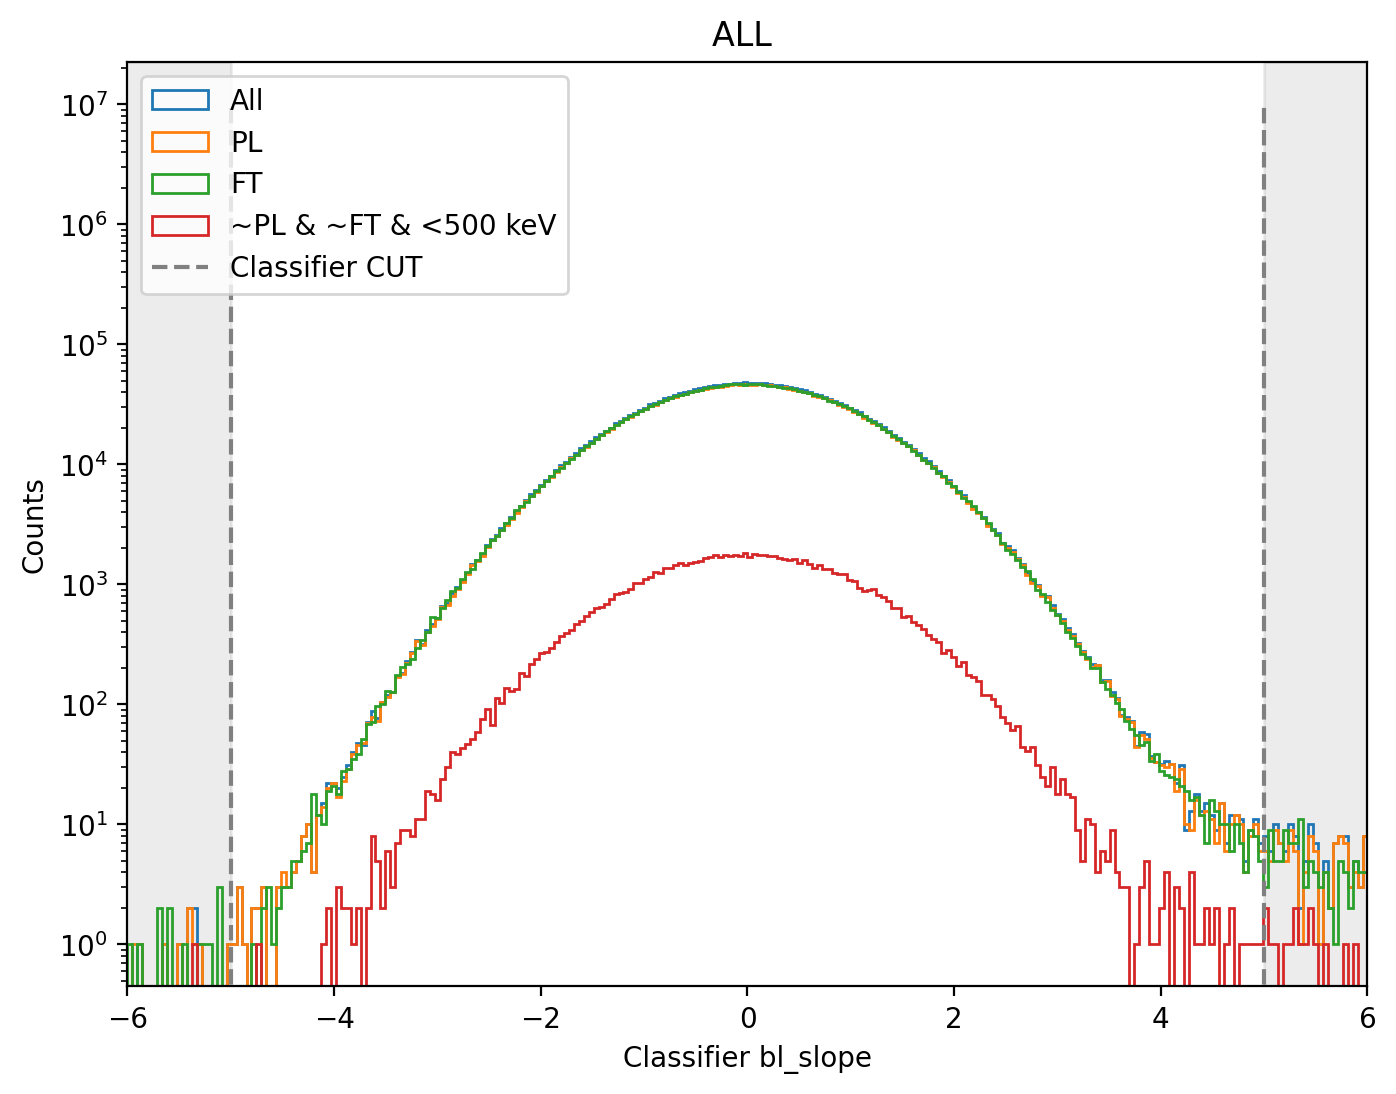

In [24]:
single_plot(data_ALL, params[0], title = "ALL", cmax = 6, veryLow = False);

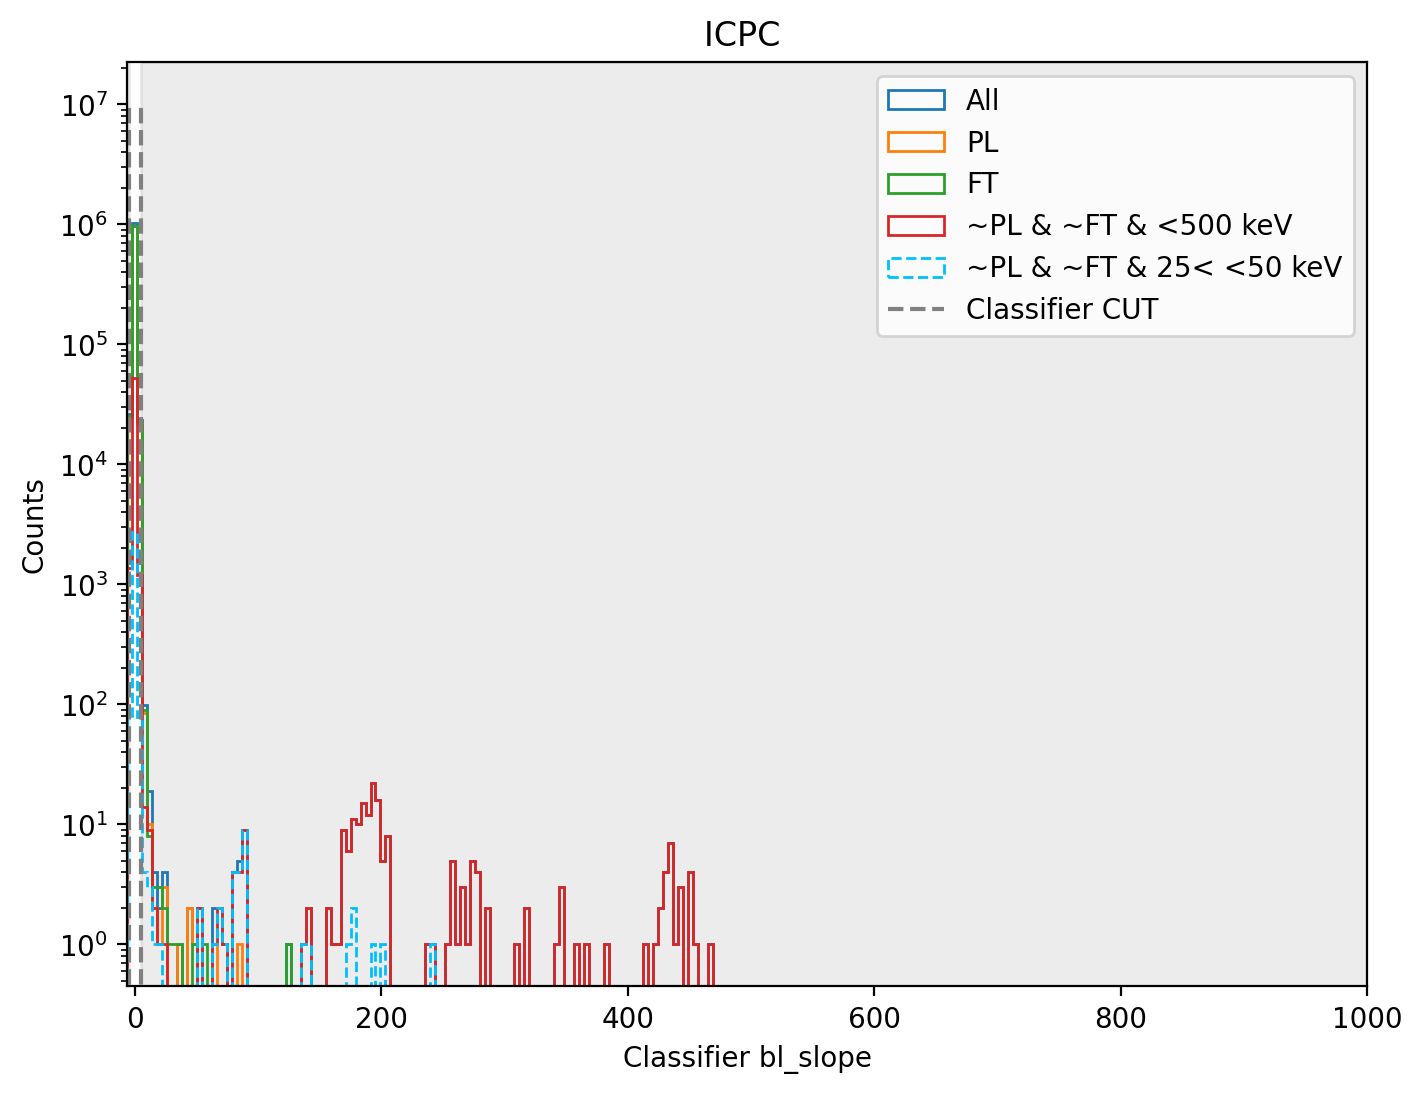

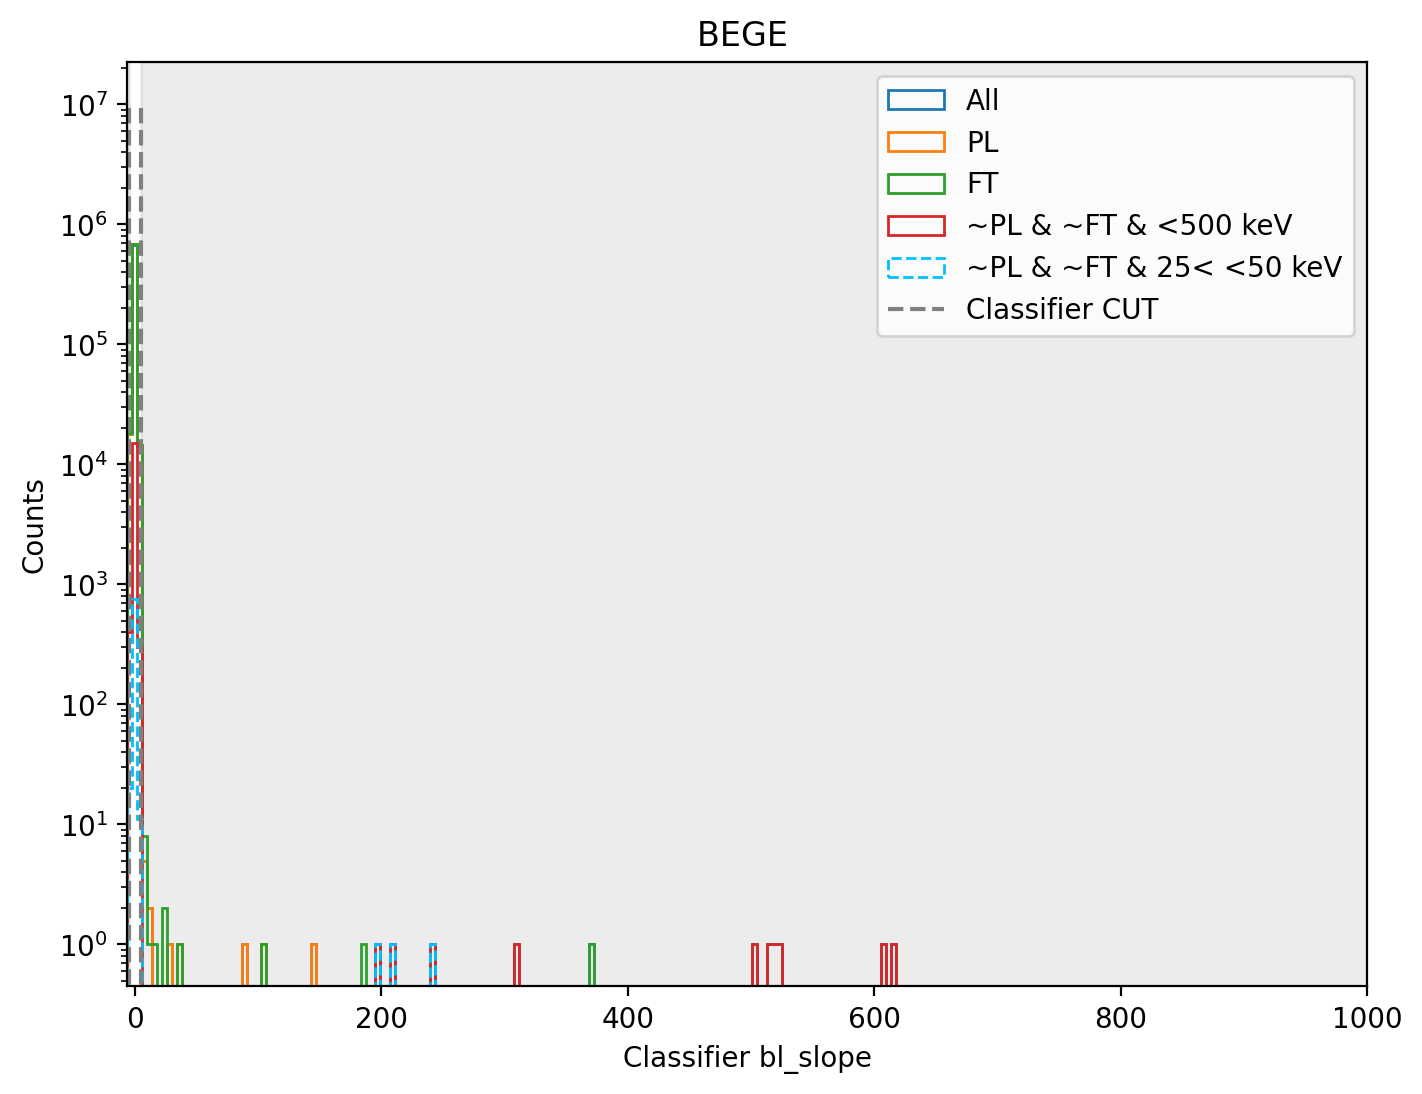

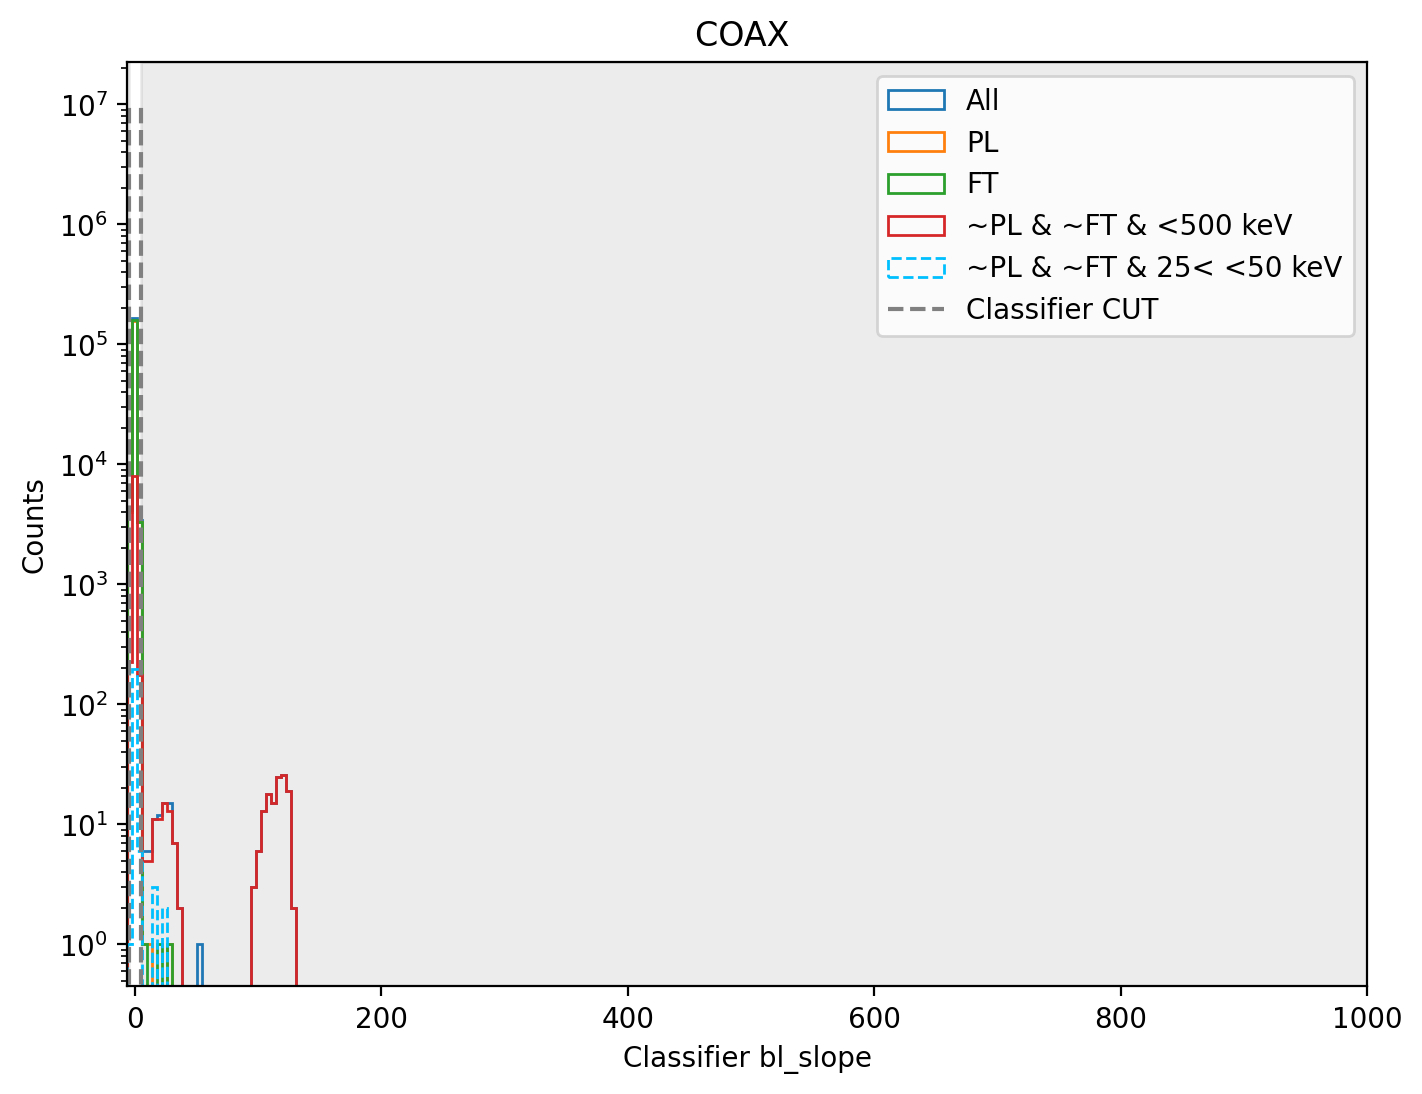

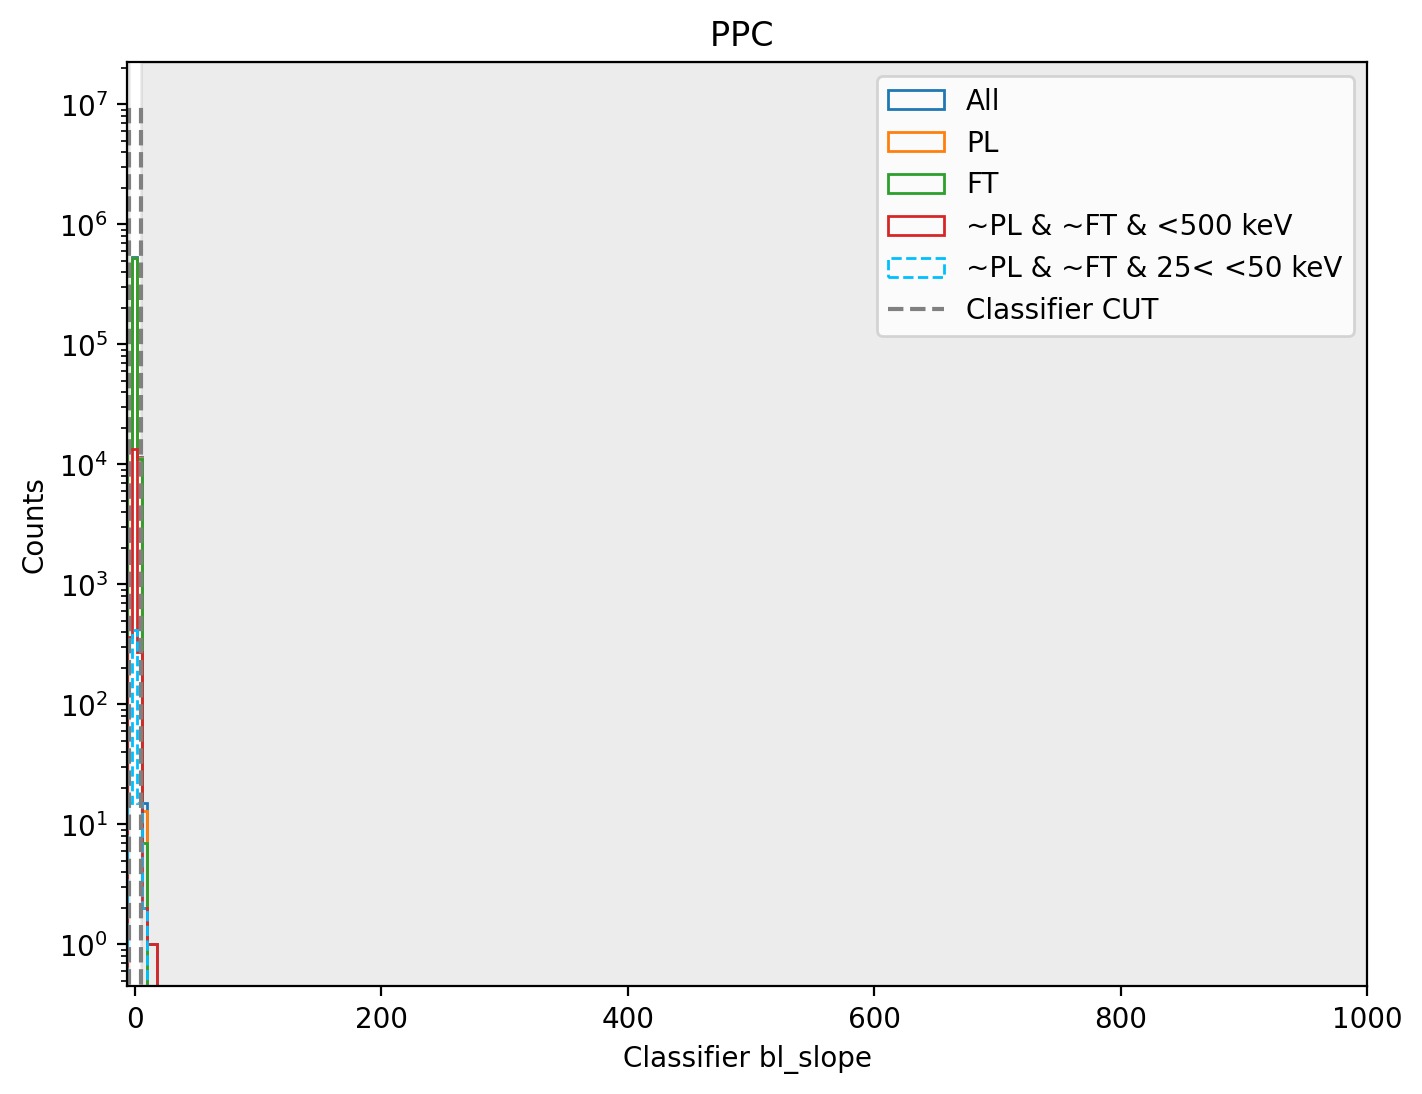

In [25]:
single_plot(data_ICPC, params[0], title = "ICPC", cmax = 1000, veryLow = True)
single_plot(data_BEGe, params[0], title = "BEGE", cmax = 1000, veryLow = True)
single_plot(data_COAX, params[0], title = "COAX", cmax = 1000, veryLow = True)
single_plot(data_PPC, params[0], title = "PPC", cmax = 1000, veryLow = True)